In [215]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from matplotlib import MatplotlibDeprecationWarning

df1 = pd.read_csv('LungCancerPrediction1.csv') 
df2 = pd.read_csv('LungCancerPrediction2.csv')
df3 = pd.read_csv('LungCancerPrediction3.csv')

#remove all duplicates  

df1 = df1.loc[df1.duplicated(keep='first') == False]  

df1 = df1.dropna()  

df2 = df2.loc[df2.duplicated(keep='first') == False]  

df2 = df2.dropna()  

df3 = df3.loc[df3.duplicated(keep='first') == False]  

df3 = df3.dropna()  

#used to confirm the relation between causes of lung cancer to intensity of lung cancer df1_expected_relation = df1.filter(['index', 'Age', 'Air Pollution', 'Dust Allergy', 'Genetic Risk', 'chronic Lung Disease', 'Smoking', 'Passive Smoker', 'Coughing of Blood', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Level'])  

#used to confirm the relation between unlikely causes of lung cancer df1_unexpected_relation = df1.filter(['index', 'Gender', 'Alcohol use', 'OcciPational Hazards', 'Balanced Diet', 'Obesity', 'Chest Pain', 'Fatigue', 'Weight Loss', 'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough','Snoring', 'Level'])  

#Potentially useful conversion for comparison  

df2 = df2.replace('Male', 1)  

df2 = df2.replace('Female', 2)  

df2 = df2.replace('High', 3)  

df2 = df2.replace('Medium', 2)  

df2 = df2.replace('Low', 1)  

df2 = df2.replace('No', 1)  

df2 = df2.replace('Yes', 2)  

df2 = df2.replace('None', 0)  

df2 = df2.replace('Moderate', 1)  

df2 = df2.replace('Heavy', 2)  

#used to confirm the relation between causes of lung cancer to intensity of lung cancer  

df2_expected_relation = df2.filter(['patient_id', 'age', 'pack_years', 'radon_exposure', 'asbestos_exposure', 'secondhand_smoke_exposure', 'copd_diagnosis', 'family_history', 'lung_cancer'])  

#used to confirm the relation between unlikely causes of lung cancer  

df2_unexpected_relation = df2.filter(['patient_id', 'gender', 'alcohol_consumption', 'lung_cancer'])  

df3 = df3.replace('M', 1)  

df3 = df3.replace('F', 2)  

df3 = df3.replace('NO', 1)  

df3 = df3.replace('YES', 2)  

#used to confirm the relation between causes of lung cancer to intensity of lung cancer  

df3_expected_relation = df3.filter(['AGE', 'SMOKING', 'YELLOW_FINGERS', 'CHRONIC_DISEASE', 'WHEEZING', 'SHORTNESS_OF_BREATH', 'SWALLOWING_DIFFICULTY', 'LUNG_CANCER'])  

#used to confirm the relation between unlikely causes of lung cancer  

df3_unexpected_relation = df3.filter(['GENDER', 'ANXIETY', 'PEER_PRESSURE', 'FATIGUE', 'ALLERGY', 'ALCOHOL_CONSUMING', 'COUGHING', 'CHEST_PAIN', 'LUNG_CANCER']) 




In [216]:
df1["ID"] = range(1, len(df1)+1) 

df2["ID"] = range(1, len(df2)+1) 

df3["ID"] = range(1, len(df3)+1) 

df1_sorted = df1.sort_values(by="Age") # Sort by Age df2_sorted = df2.sort_values(by="pack_years", ascending=False) # Sort by pack_years descending df3_sorted = df3.sort_values(by=["AGE", "SMOKING"]) # Sort by AGE then SMOKING 

inner_merge = pd.merge(df1, df2, how="inner", on="ID")   # Only common rows 

left_merge = pd.merge(df1, df2, how="left", on="ID")     # Keep all df1 rows 

right_merge = pd.merge(df1, df2, how="right", on="ID")   # Keep all df2 rows 

outer_merge = pd.merge(df1, df2, how="outer", on="ID")   # Keep all rows from both 

 

merged_all = df1.merge(df2, on="ID", how="inner").merge(df3, on="ID", how="inner") 

merged_all.head() 

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,0,P1,33,1,2,4,5,4,3,2,...,2,1,2,2,2,2,2,2,1,1
1,1,P10,17,1,3,1,5,3,4,2,...,1,2,2,2,1,1,1,2,2,1
2,2,P100,35,1,4,5,6,5,5,4,...,1,2,1,2,1,1,2,1,1,2
3,3,P1000,37,1,7,7,7,7,6,7,...,2,1,2,1,1,2,1,2,2,2
4,4,P101,46,1,6,8,7,7,7,6,...,1,2,1,2,1,1,1,1,2,1


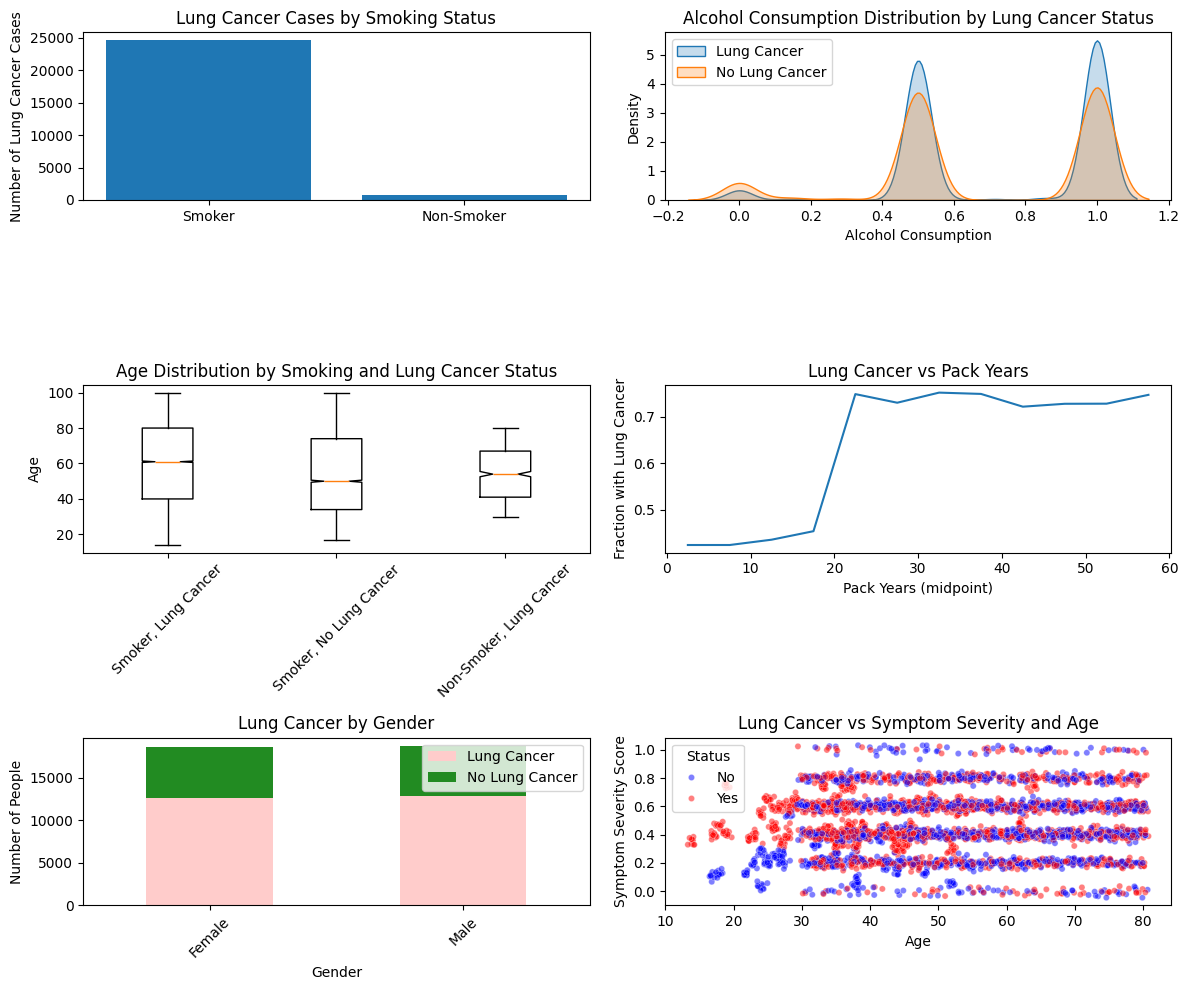

In [217]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from matplotlib import MatplotlibDeprecationWarning


#Get rid of warnings about future pandas changes
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)


df1 = pd.read_csv('LungCancerPrediction1.csv')
df2 = pd.read_csv('LungCancerPrediction2.csv')
df3 = pd.read_csv('LungCancerPrediction3.csv')


#Set all the columns to be lowercase
df1.columns = df1.columns.str.lower()
df2.columns = df2.columns.str.lower()
df3.columns = df3.columns.str.lower()

df1 = df1.drop_duplicates().dropna()
df2 = df2.drop_duplicates().dropna()
df3 = df3.drop_duplicates().dropna()


#Since all datasets have different values to determine what is male and female, create this map to conver all of them to the same values when necessary
gender_map = {1: "Male", 2: "Female", "1": "Male", "2": "Female", "M": "Male", "F": "Female", "m": "Male", "f": "Female", "Male": "Male", "Female": "Female"}


#Use gender map created above to change all male/female values to be the same
df1["gender_str"] = df1["gender"].map(gender_map)
df2["gender_str"] = df2["gender"].map(gender_map)
df3["gender_str"] = df3["gender"].map(gender_map)


#Create bins for lung_cancer in df1 of low being no lung cancer (0), and mmedium/high being lung cancer
df1["lung_cancer_bin"] = df1["level"].str.lower().map({"low": 0, "medium": 1, "high": 1})
#Replace Yes/YES with 1 (lung cancer) and No/NO with 2 (no lung cancer), and create the same bin column
df2["lung_cancer"] = df2["lung_cancer"].replace({"YES": 1, "NO": 0, "Yes": 1, "No": 0})
df2["lung_cancer_bin"] = df2["lung_cancer"]

#create lung cancer bins, same as above
df3["lung_cancer_bin"] = np.where(df3["lung_cancer"] == "YES", 1, 0)


#Create a smoker column in each. df1 & df2: when smoking is greater than 0, set 1 value (smoking), otherwise 2
df1["smoker"] = np.where(df1["smoking"] > 0, 1, 2)
df2["smoker"] = np.where(df2["pack_years"] > 0, 1, 2)
#df3: everyone smokes in df3, so just set equal to the severity score
df3["smoker"] = df3["smoking"]


#Create a df combining the three datasets containing smoker, age, and lung_cancer_bin columns, which all 3 DF's have
plot_df = pd.concat([df1[["smoker", "lung_cancer_bin", "age"]], df2[["smoker", "lung_cancer_bin", "age"]], df3[["smoker", "lung_cancer_bin", "age"]]], ignore_index=True)

#Count the number of people with lung cancer, as 1 = lung cancer, 0 = no lung cancer, so total score is just total number of people with lung cancer
counts = plot_df.groupby("smoker")["lung_cancer_bin"].sum()


#Create dataframes for alcohol consumption based on each dataframe, giving them scores of 0-1 based on consumption
df1_alcohol = df1["alcohol use"].copy()
#Since scores go from 1-8 in df1, use this formula to determine a value for each alcohol consumption level
df1_alcohol = (df1_alcohol - df1_alcohol.min()) / (df1_alcohol.max() - df1_alcohol.min())
#Since df2 has values of "None", "Moderate", and "Heavy" alcohol consumption, assign these values scores
df2_alcohol = df2["alcohol_consumption"].replace({"None": 0, "Moderate": 0.5, "Heavy": 1})
#Give 2 a value of 0 for no alcohol, 1 stays 1 to say they consume alcohol
df3_alcohol = df3["alcohol_consuming"].replace({2: 0, 1: 1})


#Combine the three alcohol dataframes into one for graphing
alcohol_df = pd.DataFrame({"alcohol": pd.concat([df1_alcohol, df2_alcohol, df3_alcohol], ignore_index=True), "lung_cancer": pd.concat([pd.Series(df1["lung_cancer_bin"]), pd.Series(df2["lung_cancer_bin"]), pd.Series(df3["lung_cancer_bin"])], ignore_index=True)})


#Create three different dataframes, each for a different combination of smoking/non-smoking and lung cancer/no lung cancer, and collect their ages
smoker_lc = plot_df[(plot_df["smoker"] == 1) & (plot_df["lung_cancer_bin"] == 1)]["age"]
smoker_no_lc = plot_df[(plot_df["smoker"] == 1) & (plot_df["lung_cancer_bin"] == 0)]["age"]
nonsmoker_lc = plot_df[(plot_df["smoker"] == 2) & (plot_df["lung_cancer_bin"] == 1)]["age"]
#Create list of the three dataframes to use for graphing
double_box = [smoker_lc, smoker_no_lc, nonsmoker_lc]
#Create labels for graph
double_box_labels = ["Smoker, Lung Cancer", "Smoker, No Lung Cancer", "Non-Smoker, Lung Cancer"]


#Calculate pack years, as df1 and df3 do not have pack years. Assuming that the average individual starts smoking at age 16, we are subtracting 16 from age to get an estimate of how many pack years they have smoked
df1["pack_years_estimated"] = df1.apply(lambda x: max(0, int(x["age"]) - 16) if x["smoking"] >= 3 else 0, axis=1)
df3["pack_years_estimated"] = df3.apply(lambda x: max(0, int(x["age"]) - 16) if x["smoking"] == 1 else 0, axis=1)
#df2 contains how many years someone has smoked, so just set this column value to the original dataframe data
df2["pack_years_estimated"] = df2["pack_years"]


#Combine all three dataframes using only the pack years and whether they have cancer or not
df_pack = pd.concat([df1[["pack_years_estimated", "lung_cancer_bin"]], df2[["pack_years_estimated", "lung_cancer_bin"]], df3[["pack_years_estimated", "lung_cancer_bin"]]], ignore_index=True)


#Create bin lines from 0 to 60 in intervals of 5 for number of pack years
bins_line = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
#Use the midpoint of these bins to get a more accurate representation of the data for graphing
bin_line_mid = [2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5]
#Cut the data using the bins created above
df_pack["pack_year_bin"] = pd.cut(df_pack["pack_years_estimated"], bins=bins_line)


#Create a dataframe collecting gender and lung cancer status from each dataset
df_gender = pd.concat([df1[["gender_str", "lung_cancer_bin"]], df2[["gender_str", "lung_cancer_bin"]], df3[["gender_str", "lung_cancer_bin"]]], ignore_index=True)


#Grouping by gender, find how many people have lung cancer for each gender, since total sums of 1's and 0's will only give total number of those with lung cancer
lung_cancer_counts = df_gender.groupby("gender_str")["lung_cancer_bin"].sum()
#Grouping by gender, find how many people do not have lung cancer for each gender by summing how many times 0's appear
no_lung_cancer_counts = df_gender.groupby("gender_str")["lung_cancer_bin"].apply(lambda x: (x == 0).sum())
#Create a dataframe containing columns of lung canccer and no lung cancer and their data based on gender
counts_df = pd.DataFrame({"Lung Cancer": lung_cancer_counts, "No Lung Cancer": no_lung_cancer_counts})


#Create a list of all symptoms to look at for df1
symptom_cols_1 = ["wheezing", "shortness of breath", "chest pain", "fatigue", "coughing of blood"]
#Since df1 has a scale of 1-8 on severity, use the formula of (the current value -1)/8 to calculate a severity score between 0-1, similar to how the other dataframes do it
df1[symptom_cols_1] = (df1[symptom_cols_1] - 1) / 8
#Use those values and store them in the dataframe under "symptom_score" column
df1["symptom_score"] = df1[symptom_cols_1].sum(axis=1) / len(symptom_cols_1)

#Create a list of all symptoms to look at for df3
symptom_cols_3 = ["wheezing", "shortness_of_breath", "chest_pain", "fatigue", "coughing"]
#Looking at where the value of severity is 2, then assign it a value of 1, and ot herwise assign it a 0
df3[symptom_cols_3] = df3[symptom_cols_3].apply(lambda x: np.where(x == 2, 1, 0))
#Use those values and store them in the dataframe under "symptom_sccore" column
df3["symptom_score"] = df3[symptom_cols_3].sum(axis=1) / len(symptom_cols_3)

#Create one dataframe using df1's and df3's age, symptom score and whether they have lung cancer or not as the columns to use
scatter_score = pd.concat([df1[["age", "symptom_score", "lung_cancer_bin"]], df3[["age", "symptom_score", "lung_cancer_bin"]]], ignore_index=True)
#Turn 0's to no and 1's to yes for lung cancer, to look better on the graph
scatter_score["Status"] = scatter_score["lung_cancer_bin"].map({0: "No", 1: "Yes"})


#Since most of the data points end up being the exact same for the symptom score, we give each data point a random increase in score to give a little bit of a separation effect to see clustering better
scatter_score["age_jitter"] = scatter_score["age"] + np.random.normal(0, 0.3, size=len(scatter_score))
scatter_score["score_jitter"] = scatter_score["symptom_score"] + np.random.normal(0, 0.02, size=len(scatter_score))


#Creating the subplots and axes
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))


#Graph 1, bar chart of lung cancer cases by smoking status
ax[0][0].bar([1, 2], counts.values)
ax[0][0].set_xticks([1, 2])
ax[0][0].set_xticklabels(["Smoker", "Non-Smoker"])
ax[0][0].set_ylabel("Number of Lung Cancer Cases")
ax[0][0].set_title("Lung Cancer Cases by Smoking Status")


#Graph 2, KDE plot for alcohol consumption and lung cancer status
sns.kdeplot(data=alcohol_df[alcohol_df["lung_cancer"] == 1], x="alcohol", fill=True, label="Lung Cancer", ax=ax[0][1])
sns.kdeplot(data=alcohol_df[alcohol_df["lung_cancer"] == 0], x="alcohol", fill=True, label="No Lung Cancer", ax=ax[0][1])
ax[0][1].set_xlabel("Alcohol Consumption")
ax[0][1].set_ylabel("Density")
ax[0][1].set_title("Alcohol Consumption Distribution by Lung Cancer Status")
ax[0][1].legend()


#Graph 3, box plot of age distribution for those who do/don't smoke, and for thsoe who do/don't have lung cancer
ax[1][0].boxplot(double_box, tick_labels=double_box_labels, notch=True)
ax[1][0].set_ylabel("Age")
ax[1][0].set_title("Age Distribution by Smoking and Lung Cancer Status")
ax[1][0].tick_params(axis="x", rotation=45)


#Graph 4,percentage of people with lung cancer compared to number of years smoked
pack_year_means = df_pack.groupby("pack_year_bin", observed=False)["lung_cancer_bin"].mean()
ax[1][1].plot(bin_line_mid, pack_year_means)
ax[1][1].set_xlabel("Pack Years (midpoint)")
ax[1][1].set_ylabel("Fraction with Lung Cancer")
ax[1][1].set_title("Lung Cancer vs Pack Years")


#Graph 5, stacked bar chart for number of people with/without lung cancer based on gender
counts_df.plot(kind="bar", stacked=True, color=["#FFCCCB", "#228B22"], ax=ax[2][0])
ax[2][0].set_xlabel("Gender")
ax[2][0].set_ylabel("Number of People")
ax[2][0].set_title("Lung Cancer by Gender")
ax[2][0].tick_params(axis="x", rotation=45)
ax[2][0].legend()


#Graph 6, scatter plot of symptom severity based on age, and whether they have lung cancer or not
sns.scatterplot(data=scatter_score, x="age_jitter", y="score_jitter", hue="Status", palette={"No": "blue", "Yes": "red"}, alpha=0.5, s=20, ax=ax[2][1])
ax[2][1].set_xlabel("Age")
ax[2][1].set_ylabel("Symptom Severity Score")
ax[2][1].set_title("Lung Cancer vs Symptom Severity and Age")

fig.tight_layout()
plt.show()

In [218]:
#Create list of symptoms to look at 
symptom_cols = ["wheezing", "shortness of breath", "chest pain", "fatigue"]

#Create blank list to store symptom score
pieces = []

#Loop through each sympton in the symptom list and assign each a value based on severity, adding it to the blank list
for symptom in symptom_cols:
    temp_df = df1[["lung_cancer_bin", symptom]].copy()
    temp_df.columns = ["HasLungCancer", "SymptomSeverity"]
    temp_df["Symptom_Name"]=symptom
    pieces.append(temp_df)


#Create one dataframe based on this blank list
df_symptom_stacked = pd.concat(pieces, ignore_index=True)
#Replace values of 0 with no and 1 to yes to make it more understandable
df_symptom_stacked["HasLungCancer"] = df_symptom_stacked["HasLungCancer"].replace({0: "NO", 1:"YES"})

#Group by the symptom severity and obtain the mean for each
grouped_symptoms = df_symptom_stacked.groupby(["Symptom_Name", "HasLungCancer"])["SymptomSeverity"].mean()
#Unstack the data to bring no and yes to the columns instead of index
pivoted_symptoms=grouped_symptoms.unstack()
print("\t Average Severity Score (0-1)")
print(pivoted_symptoms)

	 Average Severity Score (0-1)
HasLungCancer              NO       YES
Symptom_Name                           
chest pain           0.229373  0.516858
fatigue              0.146452  0.448529
shortness of breath  0.187294  0.499641
wheezing             0.196782  0.412482


In [219]:
#Create a copy of the plot_df dataframe using age, smoker status and lung cancer status
df_grid=plot_df[["age", "smoker", "lung_cancer_bin"]].copy()

#Create groups for those under 50 and over 50
df_grid["Age_Group"] = np.where(df_grid["age"] < 50, "Under 50", "50+")

#Create groups for those who smoke and those who don't
df_grid["smoker_status"] = np.where(df_grid["smoker"] == 1, "Smoker", "Non-Smoker")

#Group by the age groups and smoking status, and then see if they have lung cancer or not, and find the mean of that data
grouped_data = df_grid.groupby(["Age_Group", "smoker_status"])["lung_cancer_bin"].mean()

#Unstack the data to bring non-smoker and smoker data to the columns instead of index values
pivoted_risk = grouped_data.unstack()
print("\tLung Cancer Probability")
print(pivoted_risk)

	Lung Cancer Probability
smoker_status  Non-Smoker    Smoker
Age_Group                          
50+              0.503363  0.735755
Under 50         0.528399  0.613548


In [220]:
#Create one dataframe from all three datasets using gender, smoking status and lung cancer status
df_demographics = pd.concat([df1[["gender_str", "smoker", "lung_cancer_bin"]], df2[["gender_str", "smoker", "lung_cancer_bin"]], df3[["gender_str", "smoker", "lung_cancer_bin"]]], ignore_index=True)

#Assign "Smoker" to values of 1 in the dataframe and "Non-Smoker" to 0
df_demographics["Status"] = np.where(df_demographics["smoker"] == 1, "Smoker", "Non-Smoker")

#Gruop by gender and smoking status, find total number of people with lung cancer
grouped_demographics = df_demographics.groupby(["gender_str", "Status"])["lung_cancer_bin"].sum()

#Unstack the data, bringing "Non-Smoker" and "Smoker" from index values to column values
demographic = grouped_demographics.unstack()
print("\tTotal Lung Cancer Cases by Gender and Smoking")
print(demographic)

	Total Lung Cancer Cases by Gender and Smoking
Status      Non-Smoker  Smoker
gender_str                    
Female             389   12187
Male               367   12444
